With this model, im aiming for interpretability - to understand *what* drives purchasing in a given session. Therefore I'll be building a logistic regression model, in order to see the biggest contributors to purchase outcomes.

In [1]:
# The robust scaler is the best choice for handling the extreme outliers in the duration columns.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [3]:
df = pd.read_csv('../data/clean_online_shoppers_dataset.csv')

X = df.drop(columns=['Revenue'])
y = df['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True))
print("\nClass distribution (test):")
print(y_test.value_counts(normalize=True))

Train shape: (9859, 32) (9859,)
Test shape: (2465, 32) (2465,)

Class distribution (train):
Revenue
False    0.845218
True     0.154782
Name: proportion, dtype: float64

Class distribution (test):
Revenue
False    0.84503
True     0.15497
Name: proportion, dtype: float64


In [4]:
binary_cols = [col for col in X_train.columns if X_train[col].nunique() == 2 and set(X_train[col].unique()).issubset({0,1})]

continuous_cols = [col for col in X_train.columns if col not in binary_cols]

print("Binary columns:", binary_cols)
print("Continuous columns:", continuous_cols)

Binary columns: ['TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_8', 'TrafficType_10', 'TrafficType_11', 'TrafficType_13', 'TrafficType_20', 'TrafficType_Other', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_New_Visitor', 'is_special_day', 'Visited_Informational', 'has_bounce', 'high_exit_rate']
Continuous columns: ['Administrative', 'Informational', 'ProductRelated', 'ExitRates', 'Administrative_Duration_log', 'PageValues_log', 'ProductRelated_Duration_sqrt']


In [5]:
scaler = RobustScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(X_train_scaled[continuous_cols].describe())
print("\nBinary cols untouched, sample:")
print(X_train_scaled[binary_cols].head())

       Administrative  Informational  ProductRelated    ExitRates  \
count     9859.000000    9859.000000     9859.000000  9859.000000   
mean         0.328913       0.502384        0.449279     0.495946   
std          0.834148       1.254681        1.461921     1.357794   
min         -0.250000       0.000000       -0.590164    -0.704627   
25%         -0.250000       0.000000       -0.360656    -0.305025   
50%          0.000000       0.000000        0.000000     0.000000   
75%          0.750000       0.000000        0.639344     0.694975   
max          6.500000      24.000000       22.524590     4.893779   

       Administrative_Duration_log  PageValues_log  \
count                  9859.000000     9859.000000   
mean                      0.050019        0.630194   
std                       0.519846        1.274912   
min                      -0.456631        0.000000   
25%                      -0.456631        0.000000   
50%                       0.000000        0.000000   


## Unsupervised Modeling - K-Means Clusters

In [6]:
inertias = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled[continuous_cols])
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled[continuous_cols], labels))

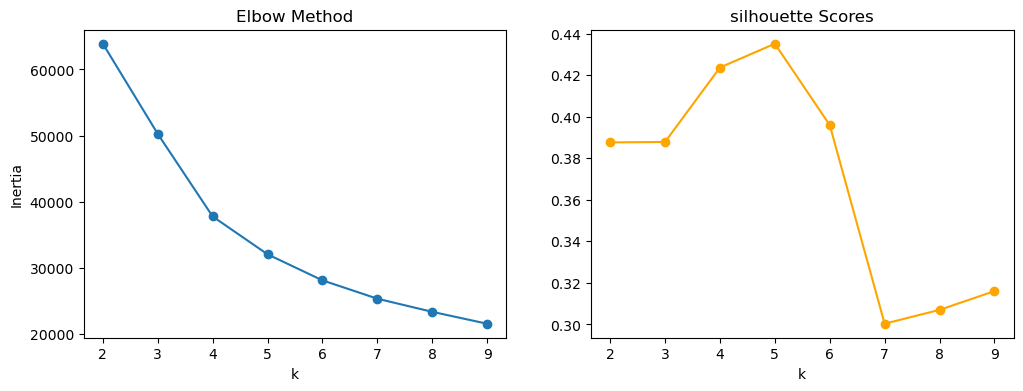

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(K_range, inertias, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(K_range, silhouette_scores, marker='o', color='orange')
ax[1].set_title("silhouette Scores")
ax[1].set_xlabel("k")
plt.show()

The elbow is at k=4, after which inertia decreases at a smaller rate.
Although the silhouette score peak is at k=5, k=4 is a close second, and only ~1.5 points less.
Based off of these metrics, centroids set at 4 will provide the most meaningful groups.

In [8]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_scaled[continuous_cols])

X_train_clustered = X_train_scaled[continuous_cols].copy()
X_train_clustered['Cluster'] = cluster_labels

print(X_train_clustered['Cluster'].value_counts().sort_index())

Cluster
0    6181
1    1181
2    1665
3     832
Name: count, dtype: int64


In [9]:
cluster_profile = X_train_clustered.groupby('Cluster').mean()
print(cluster_profile)

         Administrative  Informational  ProductRelated  ExitRates  \
Cluster                                                             
0              0.202475       0.270668        0.154705   0.149314   
1             -0.231583       0.014395       -0.477700   3.701409   
2              0.616967       0.555556        0.521243  -0.161312   
3              1.487380       2.810096        3.809505  -0.163658   

         Administrative_Duration_log  PageValues_log  \
Cluster                                                
0                           0.007628        0.013420   
1                          -0.432291        0.000000   
2                           0.304355        3.145152   
3                           0.540600        1.073865   

         ProductRelated_Duration_sqrt  
Cluster                                
0                            0.030954  
1                           -0.774396  
2                            0.406142  
3                            1.733827  


In [10]:
cluster_profile_export = cluster_profile.reset_index()
cluster_profile_export.to_csv('../results/data/cluster_profile_data.csv', index=False)

cluster_profile_export.head()

# Make the df into long format to feed into Tableau
cluster_profile_long = cluster_profile_export.melt(
    id_vars='Cluster',
    var_name='Variable',
    value_name='value'
)

cluster_profile_long.to_csv('../results/data/cluster_profile_long.csv', index=False)

Looking at the tables alone, the 4 clusters show distinct patterns.

Cluster 1 shows the lowest number of pages visited for each type, with higher than typical exit rates, average page values, and less time spent on both administrative and product pages.

Cluster 2 shows the opposite of that- a higher number of page visits for all types, lower exit rates, longer page visit durations, and higher page values.

The two other clusters sit with values in between the other 2 clusters, sharing the same pattern but to a lesser magnitude.

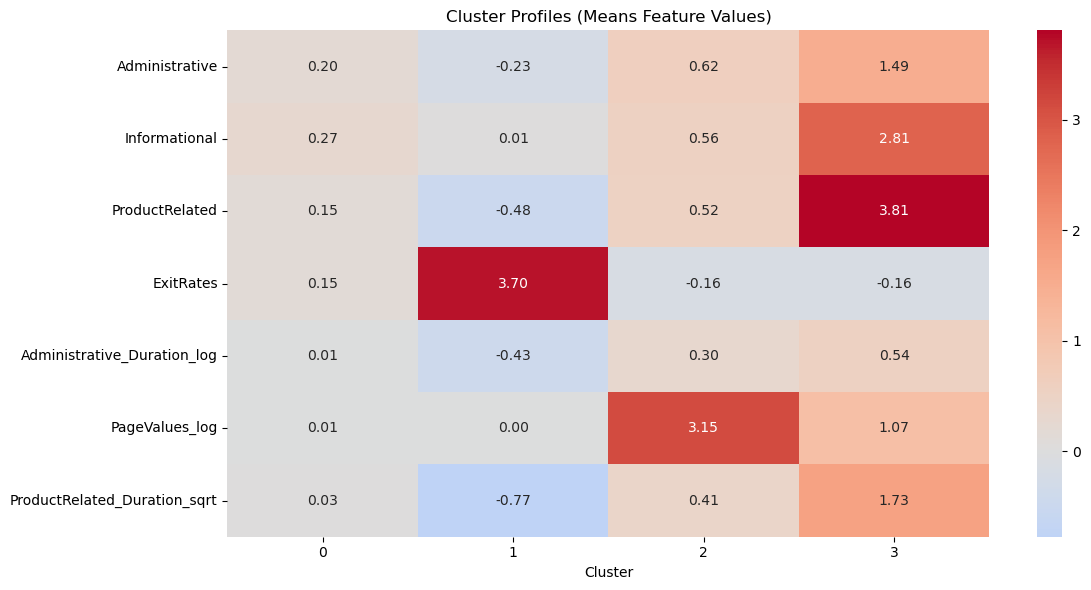

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile.T, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title("Cluster Profiles (Means Feature Values)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

In [12]:
X_train_clustered['Revenue'] = y_train.values

revenue_by_cluster = X_train_clustered.groupby('Cluster')['Revenue'].mean()
print("\nPurchase rate (Revenue=True) by cluster:")
print(revenue_by_cluster.sort_values(ascending=False))


Purchase rate (Revenue=True) by cluster:
Cluster
2    0.611411
3    0.272837
0    0.044168
1    0.006774
Name: Revenue, dtype: float64


In [13]:
print(X_train_clustered['Cluster'].value_counts().sort_index())

Cluster
0    6181
1    1181
2    1665
3     832
Name: count, dtype: int64


The highest revenue generating cluster is cluster 0, with 61% of sessions making a purchase. They consist of exceptionally higher PageValues, and higher page durations and page visits, as well as lower exit rates. This cluster makes up 17% of the sessions.

The second highest revenue cluster is cluster 2, with ~28% of sessions ending in a purchase. These sessions consist of noticeably higher page visit numbers (especially for product related pages), visit durations, higher page values, and lower exit rates, indicative of an active shopper exploring their options, and converting at a moderate rate- half that of cluster 0. Cluster 2 made up ~9% of sessions in the training data.

Cluster 3 had the third largest purchase rate, however, only 4% of sessions ended with a purchase. Features showed typical values, with the number of page visits slightly elevated, indicating casual browsing, short sessions, and a small conversion rate. This cluster made up 62% of all sessions in the training data.

Cluster 1 showed the smallest purchase rate, with only 0.68% of sessions ending in a purchase. This cluster showed a very high exit rate, and comparatively lower page visits and visit durations than all other clusters.

## How Distinct Are the Clusters? - PCA

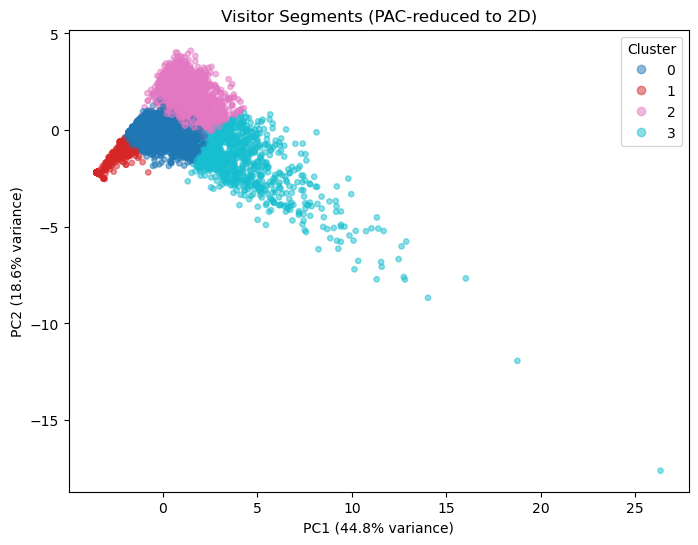

In [14]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca_2d = pca_viz.fit_transform(X_train_scaled[continuous_cols])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.5, s=15)
plt.xlabel(f"PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("Visitor Segments (PAC-reduced to 2D)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

The 2D visualization of PCA shows 4 groups that have distinct shapes and spread.

Cluster 1 shows the least variation in it's points, with high exit rates and similar exit behavior across sessions.

Cluster 2 represents a group that spends a long time browsing- but with much more variation between independent sessions on *how long* they browse.

Cluster 0 and 3 are similar in that they are less distinct while still being visually separated. Cluster 3 represents typical/average behavior, while Cluster 0 engages with more pages,for longer, and with much higher page values.


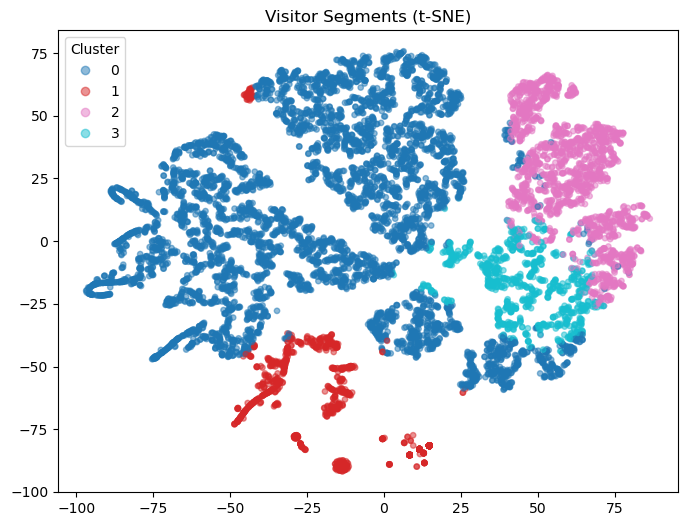

In [15]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_scaled[continuous_cols])

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=cluster_labels, cmap='tab10', alpha=0.5, s=15)
plt.title("Visitor Segments (t-SNE)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

Cluster 3 (Cyan) dominates the space due to it's high session count, spreading across the space, at times sharing it with other clusters.

Cluster 0 (Blue) represent sessions that share high page values- a concentrated blob, distinctly separated from the others.

Cluster 2 (Magenta) is in between the previous two clusters. In the PCA plot it has more variance and spread because of inner-cluster variation, but here it is a more distinct blob, located in between the cyan and blue cluster- at times sharing characteristics with them.

Cluster 1 (Red) is on an opposite end of the plot from the blue cluster, with some inner-cluster segments of points being tighter together- unlike with any other cluster in the plot.

## Logistic Regression (With Cross-Validated Regularization)

In [16]:
log_reg_final = LogisticRegressionCV(
    l1_ratios=[1.0],
    solver='liblinear',
    Cs=10,
    cv=5,
    random_state=42,
    max_iter=1000,
    scoring='roc_auc', # goes beyond measuring 'c' scores by accuracy (Revenue in the dataset is imbalanced)
    class_weight='balanced'
)

log_reg_final.fit(X_train_scaled, y_train)

print("Best C:", log_reg_final.C_)

e:\Miniconda\envs\da\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Best C: [0.35938137]


In [17]:
y_pred = log_reg_final.predict(X_test_scaled)
y_pred_proba = log_reg_final.predict_proba(X_test_scaled)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

ROC AUC: 0.9227063764757335

Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2083
        True       0.57      0.80      0.67       382

    accuracy                           0.88      2465
   macro avg       0.77      0.85      0.80      2465
weighted avg       0.90      0.88      0.88      2465


Confusion Matrix:
[[1856  227]
 [  76  306]]


Out of all sessions that did end in a purchase, the model accurately flagged 80% of them.

In [18]:
coef_df = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': log_reg_final.coef_[0]
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df_sorted = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print(coef_df_sorted.to_string())

                         feature  coefficient  abs_coef
0                      Month_Feb    -1.292427  1.292427
1                 PageValues_log     1.236076  1.236076
2                      Month_May    -1.090681  1.090681
3                      Month_Mar    -0.808185  0.808185
4                  TrafficType_5     0.807227  0.807227
5                      Month_Nov     0.804030  0.804030
6                  TrafficType_8     0.721866  0.721866
7                 TrafficType_11     0.639071  0.639071
8                 TrafficType_20     0.537494  0.537494
9                      Month_Sep     0.490536  0.490536
10                TrafficType_13    -0.457501  0.457501
11                     Month_Dec    -0.417299  0.417299
12                TrafficType_10     0.392906  0.392906
13                     ExitRates    -0.369770  0.369770
14                 TrafficType_2     0.340741  0.340741
15                     Month_Jul     0.275642  0.275642
16                 TrafficType_4     0.252435  0

February has the highest coefficient - however, looking back at my EDA, February has the lowest sample size of 184 sessions, versus May at 3364 sessions. What I missed in my EDA was that February's purchase rate across all it's sessions is 1.63%, versus the range of 10-25% amongst other months. This is an oversight which inflates February's coefficient.

Notebooks preprocessing_v2 and model_v2 followup on these findings, by implementing Month bucketing and rerunning the same logistic regression analysis to evaluate the new coefficients.